In [ ]:
# Setup — imports, plotting config, device
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os

os.makedirs("outputs", exist_ok=True)

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.dpi'] = 100

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


100%|██████████| 170M/170M [25:31<00:00, 111kB/s]


Training images: 50000
Testing images : 10000
Image shape    : (3, 32, 32)
Number of classes: 10


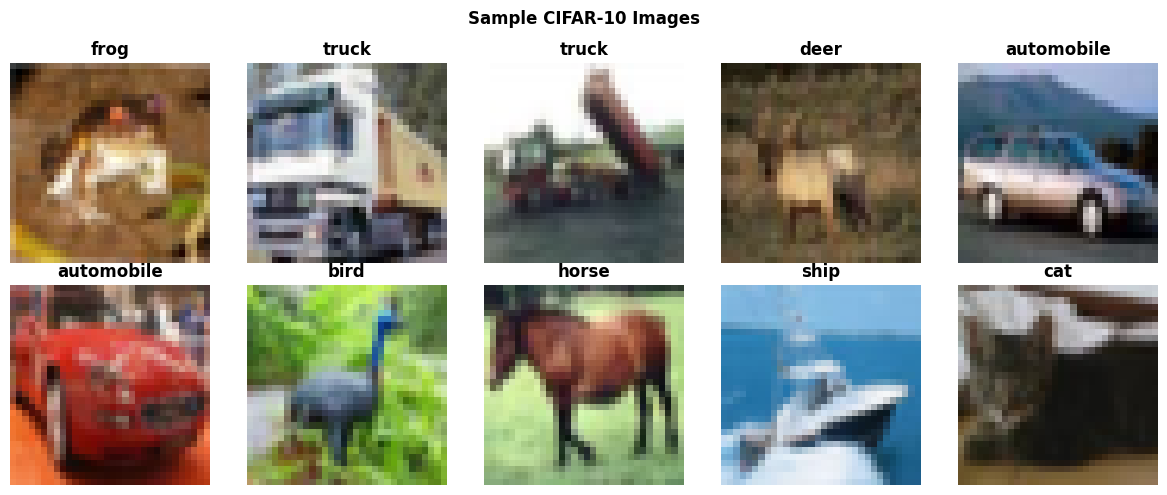

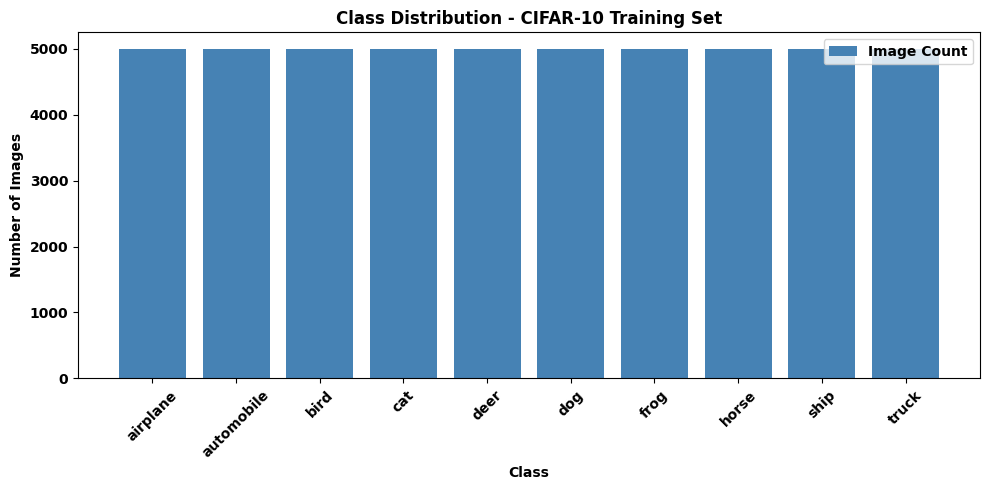

In [ ]:
# Task 1
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = train_dataset.classes

print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))
print("Image shape    :", tuple(train_dataset[0][0].shape))
print("Number of classes:", len(classes))

# --- Sample images ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(classes[label], fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/1_sample_images.png", dpi=200)
plt.show()
# Inference: The dataset covers 10 visually distinct object/animal classes at low
# resolution (32x32), which makes fine-grained features hard to see by eye.

# --- Class distribution ---
labels = [label for _, label in train_dataset]
counts = np.bincount(labels)

plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color='steelblue', label='Image Count')
plt.xlabel("Class", fontweight='bold')
plt.ylabel("Number of Images", fontweight='bold')
plt.title("Class Distribution - CIFAR-10 Training Set", fontweight='bold')
plt.xticks(rotation=45)
plt.legend(prop={'weight': 'bold'})
plt.tight_layout()
plt.savefig("outputs/2_class_distribution.png", dpi=200)
plt.show()
# Inference: All 10 classes have exactly 5000 training images each, so CIFAR-10
# is perfectly balanced and no class-imbalance handling is required.


In [ ]:
# Task 2
sample_img, _ = train_dataset[0]
sample_img = sample_img.unsqueeze(0)  # (1, 3, 32, 32)

kernel_sizes = [3, 5, 7]
print(f"{'Kernel':<10}{'Input Size':<15}{'Output Feature Map Size'}")
for k in kernel_sizes:
    conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=k, stride=1, padding=0)
    out = conv(sample_img)
    print(f"{k}x{k:<8}{sample_img.shape[-1]}x{sample_img.shape[-1]:<13}{out.shape[-1]}x{out.shape[-1]}")
# Formula check: N - F + 1  (stride=1, padding=0)


Kernel    Input Size     Output Feature Map Size
3x3       32x32           30x30
5x5       32x32           28x28
7x7       32x32           26x26


In [ ]:
# Task 3
configs = [
    {"stride": 1, "padding": 0, "name": "Stride=1, Padding=Valid(0)"},
    {"stride": 2, "padding": 0, "name": "Stride=2, Padding=Valid(0)"},
    {"stride": 1, "padding": 1, "name": "Stride=1, Padding=Same(1)"},
    {"stride": 2, "padding": 1, "name": "Stride=2, Padding=Same(1)"},
]

print(f"{'Configuration':<32}{'Output Size'}")
for cfg in configs:
    conv = nn.Conv2d(3, 8, kernel_size=3, stride=cfg["stride"], padding=cfg["padding"])
    out = conv(sample_img)
    print(f"{cfg['name']:<32}{out.shape[-1]}x{out.shape[-1]}")

Configuration                   Output Size
Stride=1, Padding=Valid(0)      30x30
Stride=2, Padding=Valid(0)      15x15
Stride=1, Padding=Same(1)       32x32
Stride=2, Padding=Same(1)       16x16


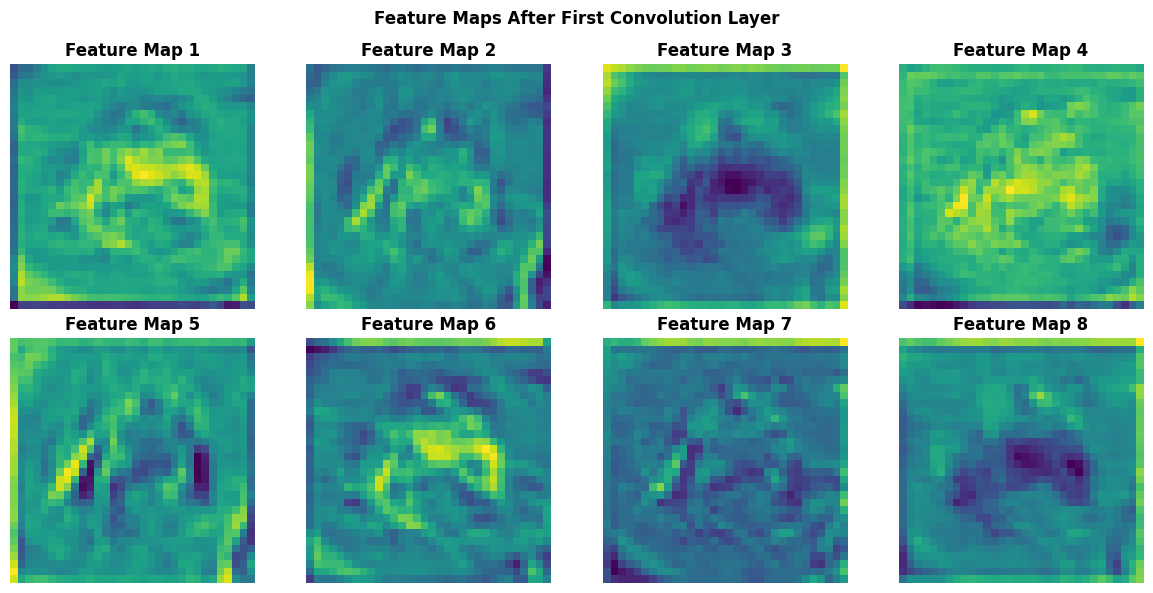

In [ ]:
# Task 4
conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
feature_maps = conv1(sample_img).detach()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, i].numpy(), cmap='viridis')
    ax.set_title(f"Feature Map {i+1}", fontweight='bold')
    ax.axis('off')
plt.suptitle("Feature Maps After First Convolution Layer", fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/7_feature_maps.png", dpi=200)
plt.show()

Input feature map size : 32
Max Pool output size   : 16
Avg Pool output size   : 16


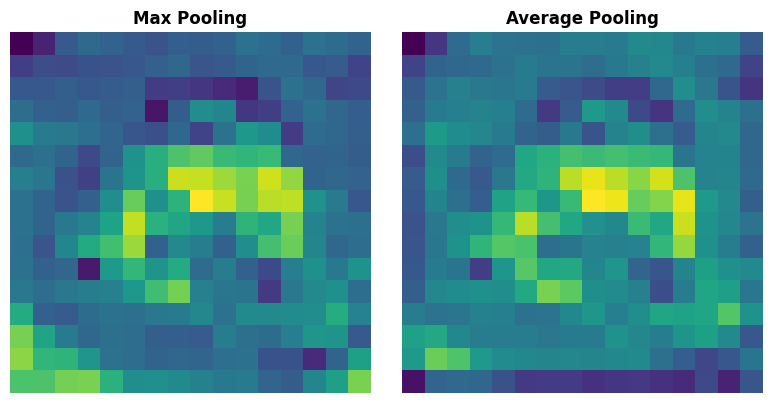

In [ ]:
# Task 5
maxpool = nn.MaxPool2d(2, 2)
avgpool = nn.AvgPool2d(2, 2)

max_out = maxpool(feature_maps)
avg_out = avgpool(feature_maps)

print("Input feature map size :", feature_maps.shape[-1])
print("Max Pool output size   :", max_out.shape[-1])
print("Avg Pool output size   :", avg_out.shape[-1])
# Both reduce the spatial size identically (2x2, stride 2); the accuracy
# comparison between the two is done as part of Task 6/7 by swapping the
# pooling layer in SimpleCNN and re-running training if required.

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(max_out[0, 0].numpy(), cmap='viridis')
axes[0].set_title("Max Pooling", fontweight='bold')
axes[0].axis('off')
axes[1].imshow(avg_out[0, 0].numpy(), cmap='viridis')
axes[1].set_title("Average Pooling", fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.savefig("outputs/pooling_comparison.png", dpi=200)
plt.show()

In [ ]:
# Task 5 - Create Training, Validation and Testing Loaders

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training samples  :", len(train_subset))
print("Validation samples:", len(val_subset))
print("Testing samples   :", len(test_dataset))

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))

Training samples  : 45000
Validation samples: 5000
Testing samples   : 10000
Training batches  : 1407
Validation batches: 157
Testing batches   : 313


Epoch [ 1/20]  Train Loss: 1.5293  Train Acc: 0.4563  Val Loss: 1.3103  Val Acc: 0.5368
Epoch [ 2/20]  Train Loss: 1.2299  Train Acc: 0.5665  Val Loss: 1.2160  Val Acc: 0.5696
Epoch [ 3/20]  Train Loss: 1.1129  Train Acc: 0.6100  Val Loss: 1.0790  Val Acc: 0.6248
Epoch [ 4/20]  Train Loss: 1.0325  Train Acc: 0.6382  Val Loss: 1.0636  Val Acc: 0.6246
Epoch [ 5/20]  Train Loss: 0.9731  Train Acc: 0.6602  Val Loss: 1.0009  Val Acc: 0.6548
Epoch [ 6/20]  Train Loss: 0.9234  Train Acc: 0.6818  Val Loss: 0.9800  Val Acc: 0.6630
Epoch [ 7/20]  Train Loss: 0.8860  Train Acc: 0.6918  Val Loss: 0.9656  Val Acc: 0.6698
Epoch [ 8/20]  Train Loss: 0.8570  Train Acc: 0.7030  Val Loss: 0.9919  Val Acc: 0.6628
Epoch [ 9/20]  Train Loss: 0.8273  Train Acc: 0.7114  Val Loss: 0.9576  Val Acc: 0.6756
Epoch [10/20]  Train Loss: 0.8032  Train Acc: 0.7208  Val Loss: 0.9758  Val Acc: 0.6644
Epoch [11/20]  Train Loss: 0.7854  Train Acc: 0.7258  Val Loss: 0.9473  Val Acc: 0.6792
Epoch [12/20]  Train Loss: 0.767

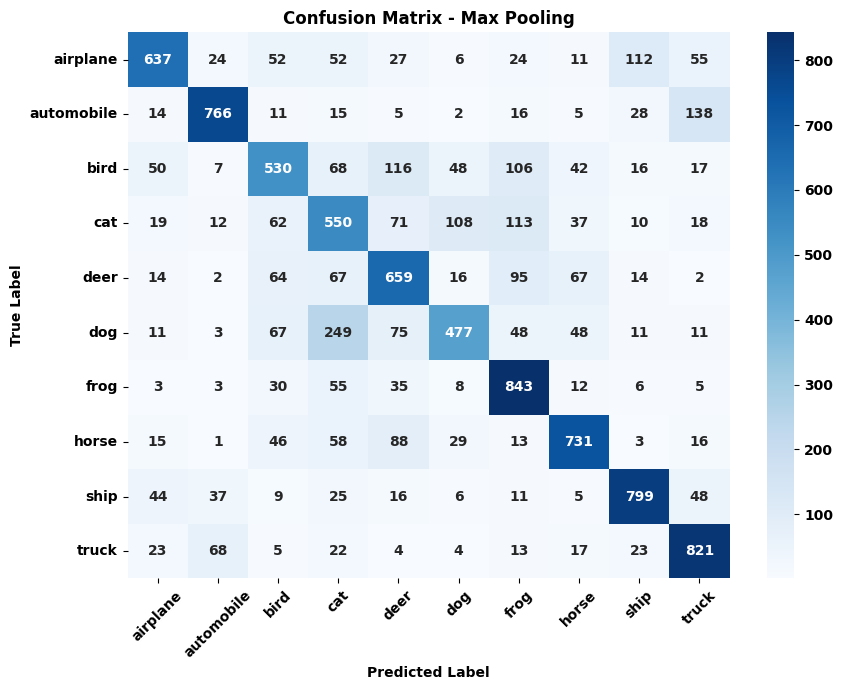

In [ ]:
# Task 6 - Max Pooling

class MaxPoolCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MaxPoolCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


max_model = MaxPoolCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    max_model.parameters(),
    lr=0.001
)

num_epochs = 20

max_train_acc_list = []
max_val_acc_list = []
max_train_loss_list = []
max_val_loss_list = []


# Training
for epoch in range(num_epochs):

    max_model.train()

    correct, total, running_loss = 0, 0, 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = max_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total


    # Validation
    max_model.eval()

    correct, total, running_loss = 0, 0, 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = max_model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    max_train_acc_list.append(train_acc)
    max_val_acc_list.append(val_acc)

    max_train_loss_list.append(train_loss)
    max_val_loss_list.append(val_loss)

    print(
        f"Epoch [{epoch+1:2d}/{num_epochs}]  "
        f"Train Loss: {train_loss:.4f}  "
        f"Train Acc: {train_acc:.4f}  "
        f"Val Loss: {val_loss:.4f}  "
        f"Val Acc: {val_acc:.4f}"
    )


# Testing
max_model.eval()

max_all_preds = []
max_all_labels = []

correct, total = 0, 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = max_model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        max_all_preds.extend(
            predicted.cpu().numpy()
        )

        max_all_labels.extend(
            labels.cpu().numpy()
        )


max_test_acc = correct / total

max_precision = precision_score(
    max_all_labels,
    max_all_preds,
    average="macro"
)

max_recall = recall_score(
    max_all_labels,
    max_all_preds,
    average="macro"
)

max_f1 = f1_score(
    max_all_labels,
    max_all_preds,
    average="macro"
)

max_num_params = sum(
    p.numel()
    for p in max_model.parameters()
    if p.requires_grad
)


print("\n========== MAX POOLING RESULTS ==========")

print(
    f"Test Accuracy       : {max_test_acc:.4f}"
)

print(
    f"Precision (macro)   : {max_precision:.4f}"
)

print(
    f"Recall (macro)      : {max_recall:.4f}"
)

print(
    f"F1-score (macro)    : {max_f1:.4f}"
)

print(
    f"Trainable parameters: {max_num_params}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        max_all_labels,
        max_all_preds,
        target_names=classes
    )
)


# Confusion Matrix
max_cm = confusion_matrix(
    max_all_labels,
    max_all_preds
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    max_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    annot_kws={"weight": "bold"}
)

plt.xlabel(
    "Predicted Label",
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontweight="bold"
)

plt.title(
    "Confusion Matrix - Max Pooling",
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    fontweight="bold"
)

plt.yticks(
    rotation=0,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/8_confusion_matrix_maxpool.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Epoch [ 1/20]  Train Loss: 1.6127  Train Acc: 0.4257  Val Loss: 1.4403  Val Acc: 0.4954
Epoch [ 2/20]  Train Loss: 1.3421  Train Acc: 0.5256  Val Loss: 1.3179  Val Acc: 0.5376
Epoch [ 3/20]  Train Loss: 1.2232  Train Acc: 0.5706  Val Loss: 1.2596  Val Acc: 0.5538
Epoch [ 4/20]  Train Loss: 1.1434  Train Acc: 0.5994  Val Loss: 1.1363  Val Acc: 0.6036
Epoch [ 5/20]  Train Loss: 1.0796  Train Acc: 0.6244  Val Loss: 1.1284  Val Acc: 0.6010
Epoch [ 6/20]  Train Loss: 1.0215  Train Acc: 0.6424  Val Loss: 1.0659  Val Acc: 0.6226
Epoch [ 7/20]  Train Loss: 0.9783  Train Acc: 0.6586  Val Loss: 1.0254  Val Acc: 0.6452
Epoch [ 8/20]  Train Loss: 0.9404  Train Acc: 0.6723  Val Loss: 1.0118  Val Acc: 0.6468
Epoch [ 9/20]  Train Loss: 0.9149  Train Acc: 0.6819  Val Loss: 0.9901  Val Acc: 0.6510
Epoch [10/20]  Train Loss: 0.8912  Train Acc: 0.6912  Val Loss: 1.0195  Val Acc: 0.6488
Epoch [11/20]  Train Loss: 0.8656  Train Acc: 0.7013  Val Loss: 0.9644  Val Acc: 0.6620
Epoch [12/20]  Train Loss: 0.845

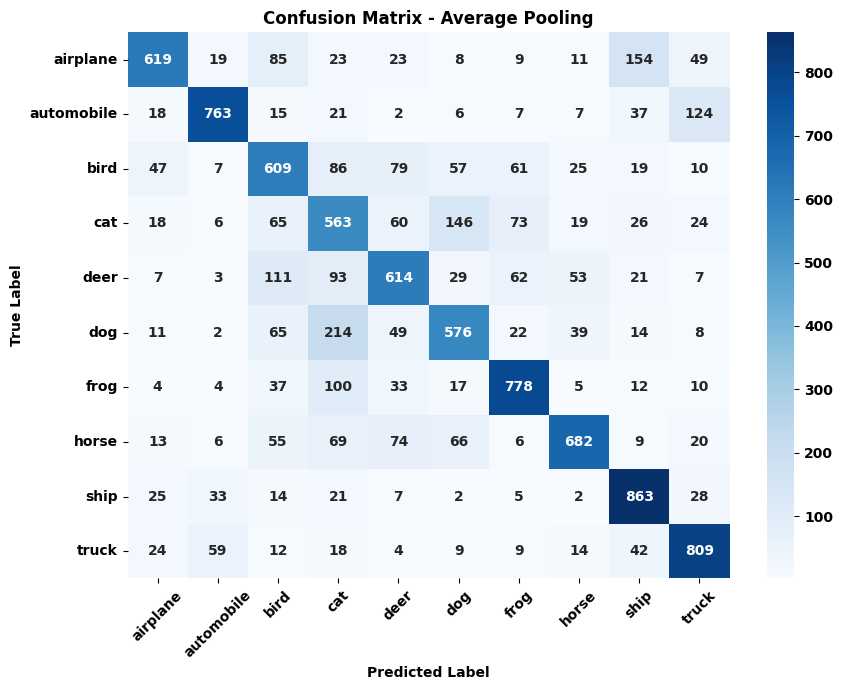

In [ ]:
# Task 6 - Average Pooling

class AvgPoolCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AvgPoolCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


avg_model = AvgPoolCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    avg_model.parameters(),
    lr=0.001
)

num_epochs = 20

avg_train_acc_list = []
avg_val_acc_list = []
avg_train_loss_list = []
avg_val_loss_list = []


# Training
for epoch in range(num_epochs):

    avg_model.train()

    correct, total, running_loss = 0, 0, 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = avg_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total


    # Validation
    avg_model.eval()

    correct, total, running_loss = 0, 0, 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = avg_model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    avg_train_acc_list.append(train_acc)
    avg_val_acc_list.append(val_acc)

    avg_train_loss_list.append(train_loss)
    avg_val_loss_list.append(val_loss)

    print(
        f"Epoch [{epoch+1:2d}/{num_epochs}]  "
        f"Train Loss: {train_loss:.4f}  "
        f"Train Acc: {train_acc:.4f}  "
        f"Val Loss: {val_loss:.4f}  "
        f"Val Acc: {val_acc:.4f}"
    )


# Testing
avg_model.eval()

avg_all_preds = []
avg_all_labels = []

correct, total = 0, 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = avg_model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        avg_all_preds.extend(
            predicted.cpu().numpy()
        )

        avg_all_labels.extend(
            labels.cpu().numpy()
        )


avg_test_acc = correct / total

avg_precision = precision_score(
    avg_all_labels,
    avg_all_preds,
    average="macro"
)

avg_recall = recall_score(
    avg_all_labels,
    avg_all_preds,
    average="macro"
)

avg_f1 = f1_score(
    avg_all_labels,
    avg_all_preds,
    average="macro"
)

avg_num_params = sum(
    p.numel()
    for p in avg_model.parameters()
    if p.requires_grad
)


print("\n========== AVERAGE POOLING RESULTS ==========")

print(
    f"Test Accuracy       : {avg_test_acc:.4f}"
)

print(
    f"Precision (macro)   : {avg_precision:.4f}"
)

print(
    f"Recall (macro)      : {avg_recall:.4f}"
)

print(
    f"F1-score (macro)    : {avg_f1:.4f}"
)

print(
    f"Trainable parameters: {avg_num_params}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        avg_all_labels,
        avg_all_preds,
        target_names=classes
    )
)


# Confusion Matrix
avg_cm = confusion_matrix(
    avg_all_labels,
    avg_all_preds
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    avg_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    annot_kws={"weight": "bold"}
)

plt.xlabel(
    "Predicted Label",
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontweight="bold"
)

plt.title(
    "Confusion Matrix - Average Pooling",
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    fontweight="bold"
)

plt.yticks(
    rotation=0,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/9_confusion_matrix_avgpool.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

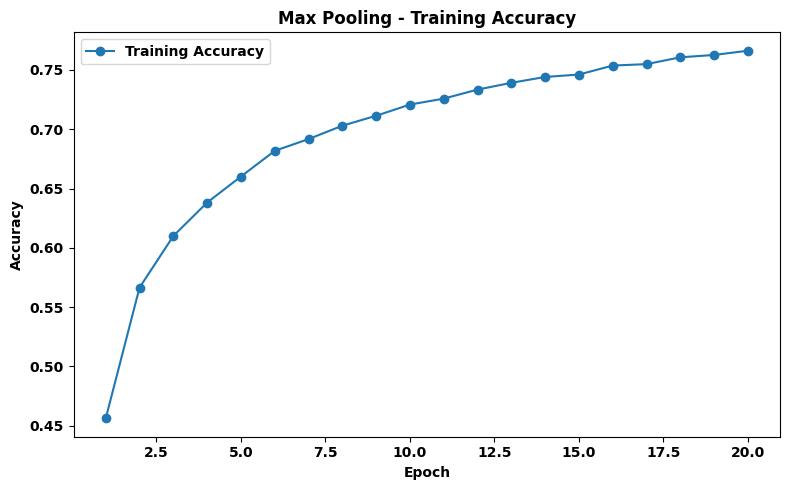

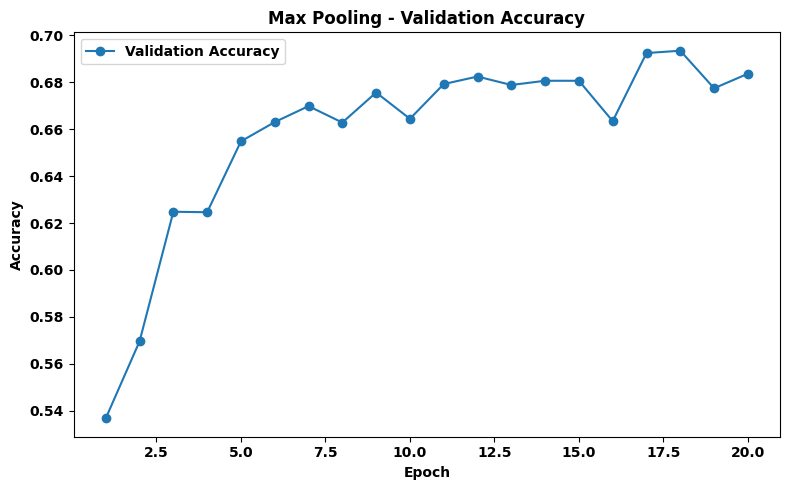

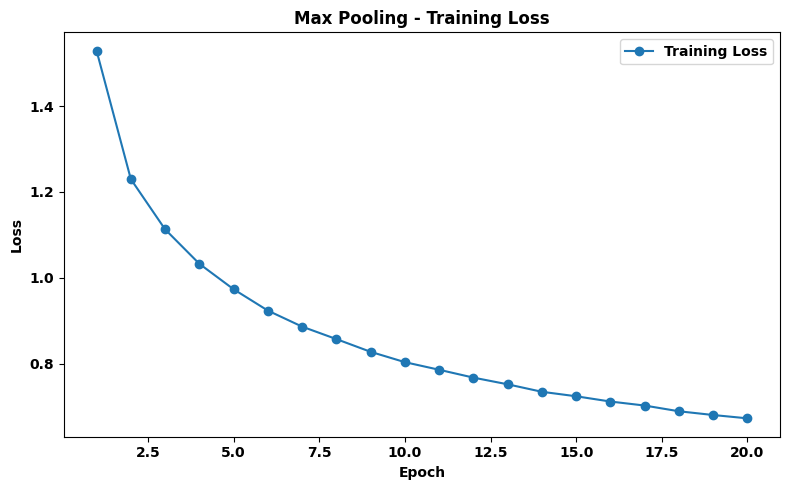

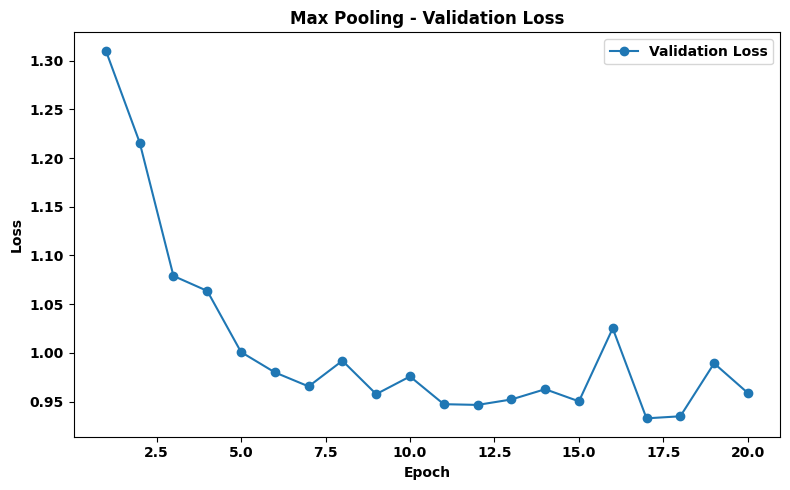

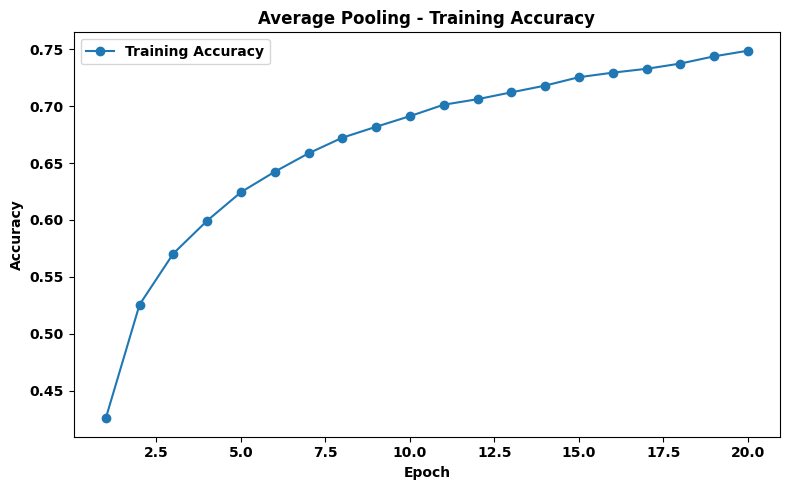

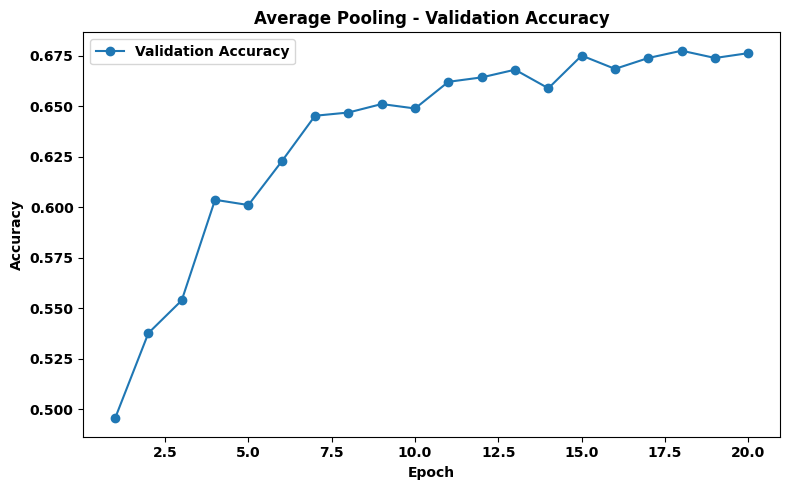

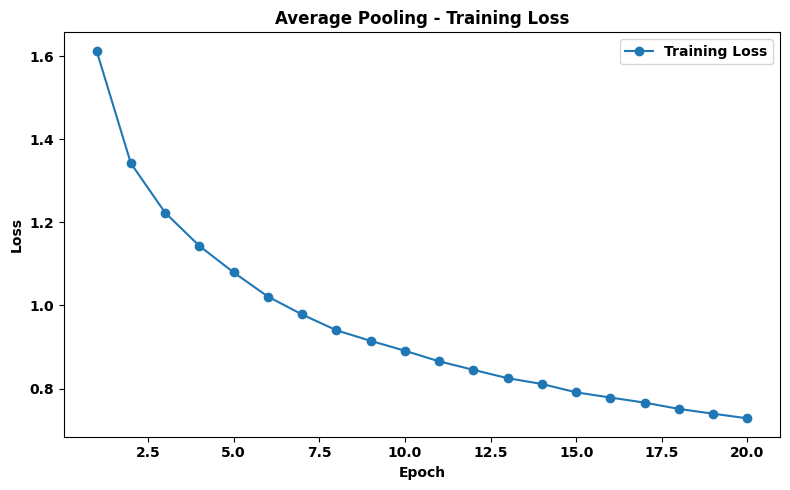

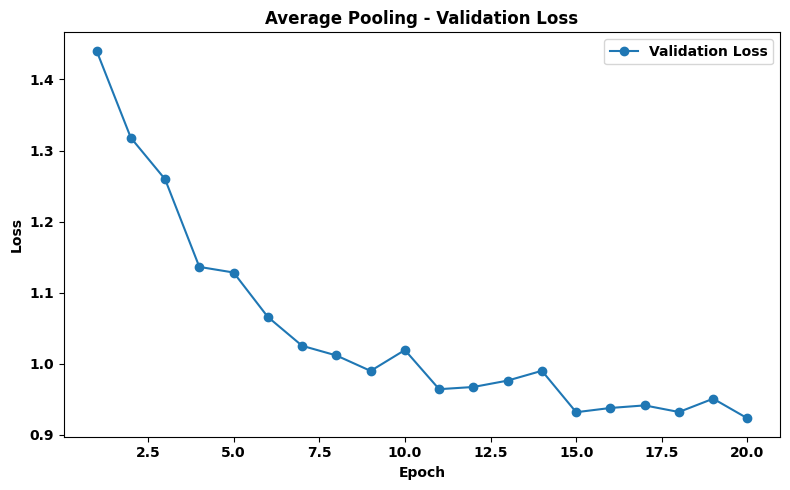

In [ ]:
# Training/Validation Accuracy & Loss Plots

epochs_range = range(1, num_epochs + 1)


# 1. Max Pooling - Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    max_train_acc_list,
    label="Training Accuracy",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Max Pooling - Training Accuracy", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/3_max_training_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 2. Max Pooling - Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    max_val_acc_list,
    label="Validation Accuracy",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Max Pooling - Validation Accuracy", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/4_max_validation_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 3. Max Pooling - Training Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    max_train_loss_list,
    label="Training Loss",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title("Max Pooling - Training Loss", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/5_max_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 4. Max Pooling - Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    max_val_loss_list,
    label="Validation Loss",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title("Max Pooling - Validation Loss", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/6_max_validation_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 5. Average Pooling - Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    avg_train_acc_list,
    label="Training Accuracy",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Average Pooling - Training Accuracy", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/7_avg_training_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 6. Average Pooling - Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    avg_val_acc_list,
    label="Validation Accuracy",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Average Pooling - Validation Accuracy", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/8_avg_validation_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 7. Average Pooling - Training Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    avg_train_loss_list,
    label="Training Loss",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title("Average Pooling - Training Loss", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/9_avg_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 8. Average Pooling - Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    avg_val_loss_list,
    label="Validation Loss",
    marker="o"
)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title("Average Pooling - Validation Loss", fontweight="bold")
plt.legend(prop={"weight": "bold"})
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.tight_layout()
plt.savefig(
    "outputs/10_avg_validation_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Exercise 1 - Output size: 32
Exercise 2 - Trainable parameters: 1792


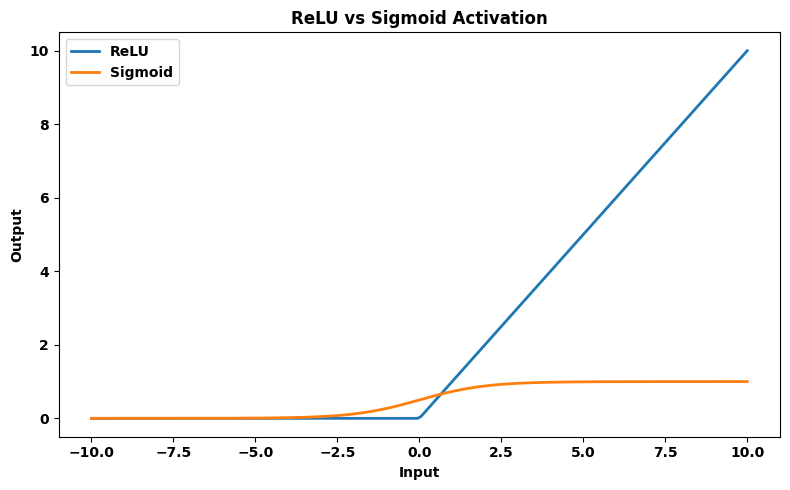

In [ ]:
# Additional Exercises
# 1. Output size for a 64x64 image, 5x5 kernel, stride 2, padding 2
N, Fk, P, S = 64, 5, 2, 2
out_size = (N - Fk + 2 * P) // S + 1
print("Exercise 1 - Output size:", out_size)

# 2. Trainable parameters: 64 filters of 3x3 kernel, RGB (3-channel) input
params = (3 * 3 * 3 + 1) * 64
print("Exercise 2 - Trainable parameters:", params)

# 3. ReLU vs Sigmoid activation comparison
x = torch.linspace(-10, 10, 200)
relu_vals = F.relu(x)
sigmoid_vals = torch.sigmoid(x)

plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), relu_vals.numpy(), label='ReLU', linewidth=2)
plt.plot(x.numpy(), sigmoid_vals.numpy(), label='Sigmoid', linewidth=2)
plt.xlabel("Input", fontweight='bold'); plt.ylabel("Output", fontweight='bold')
plt.title("ReLU vs Sigmoid Activation", fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout(); plt.savefig("outputs/relu_vs_sigmoid.png", dpi=200); plt.show()
